# Importaciones

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

from scipy.sparse import hstack, csr_matrix
from tqdm import tqdm

# Carga de Datos

In [80]:
path = "/content/drive/MyDrive/ModeladoPredictivo2026/data/cleaned_df.csv"

In [81]:
df = pd.read_csv(path)
df.head(5)

,title,text,label,title_len,text_len
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,18,871
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,18,34
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,16,1321
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,16,329
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,13,244


In [82]:
df.tail(5)

,title,text,label,title_len,text_len
61389,WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...,An email released by WikiLeaks on Sunday appea...,1,15,205
61390,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0,11,735
61391,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1,10,604
61392,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0,10,477
61393,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0,10,559


In [83]:
df.describe()

,label,title_len,text_len
count,61394.000000,61394.000000,61394.000000
mean,0.442340,12.007460,551.922484
std,0.496668,3.815937,611.146959
min,0.000000,1.000000,1.000000
25%,0.000000,9.000000,249.000000
50%,0.000000,11.000000,407.000000
75%,1.000000,14.000000,680.000000
max,1.000000,72.000000,24234.000000


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61394 entries, 0 to 61393
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      61394 non-null  object
 1   text       61394 non-null  object
 2   label      61394 non-null  int64 
 3   title_len  61394 non-null  int64 
 4   text_len   61394 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 2.3+ MB


# Vectorización

In [85]:
tfidf_text = skl.feature_extraction.text.TfidfVectorizer()
tfidf_title = skl.feature_extraction.text.TfidfVectorizer()
bow_text = skl.feature_extraction.text.CountVectorizer()
bow_title = skl.feature_extraction.text.CountVectorizer()

In [86]:
X_tfidf_text = tfidf_text.fit_transform(df["text"])
X_tfidf_title = tfidf_title.fit_transform(df["title"])
X_bow_text = bow_text.fit_transform(df["text"])
X_bow_title = bow_title.fit_transform(df["title"])

In [87]:
X_num = csr_matrix(df[["title_len", "text_len"]].values)

In [88]:
X_tfidf = hstack([X_tfidf_text, X_tfidf_title, X_num])
X_bow = hstack([X_bow_text, X_bow_title, X_num])

In [89]:
y = df["label"]

In [90]:
print(f"X_tfidf shape: {X_tfidf.shape}")
print(f"X_bow shape: {X_bow.shape}")

X_tfidf shape: (61394, 273558)
X_bow shape: (61394, 273558)


In [91]:
print(f"y shape: {y.shape}")

y shape: (61394,)


# Train-Test Split

In [92]:
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = skl.model_selection.train_test_split(
    X_tfidf, y, test_size=0.2, random_state=0, stratify=y, shuffle=True
)

In [93]:
X_bow_train, X_bow_test, y_bow_train, y_bow_test = skl.model_selection.train_test_split(
    X_bow, y, test_size=0.2, random_state=0, stratify=y, shuffle=True
)

In [94]:
print(f"TF-IDF train: {X_tfidf_train.shape} | test: {X_tfidf_test.shape}")
print(f"BoW train: {X_bow_train.shape} | test: {X_bow_test.shape}")

TF-IDF train: (49115, 273558) | test: (12279, 273558)
BoW train: (49115, 273558) | test: (12279, 273558)


# Modelos y Pipelines
Modelos:
* Linear SVM
* Regresión Logistica
* Multnomial Naïve Bayes
* Arboles de Decision

In [95]:
vectorizer_data = {
    "tf-idf": (X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test),
    "BoW": (X_bow_train,   X_bow_test,   y_bow_train,   y_bow_test)
}

In [96]:
def make_modelos():
  return {
    "SVM": skl.svm.LinearSVC(),
    "LogisticRegression": skl.linear_model.LogisticRegression(),
    "MultinomialNB": skl.naive_bayes.MultinomialNB(),
    "DecisionTreeClassifier": skl.tree.DecisionTreeClassifier()
  }

In [97]:
pipelines = {}

In [98]:
for vec_name in vectorizer_data:
    for model_name, model in make_modelos().items():
        name = f"{vec_name}_{model_name}"
        pipelines[name] = {
            "pipeline": skl.pipeline.Pipeline([(f"model_{model_name}", model)]),
            "X_train": vectorizer_data[vec_name][0],
            "X_test": vectorizer_data[vec_name][1],
            "y_train": vectorizer_data[vec_name][2],
            "y_test": vectorizer_data[vec_name][3],
        }

In [99]:
for name in pipelines:
    print(name)

tf-idf_SVM
tf-idf_LogisticRegression
tf-idf_MultinomialNB
tf-idf_DecisionTreeClassifier
BoW_SVM
BoW_LogisticRegression
BoW_MultinomialNB
BoW_DecisionTreeClassifier


# Hiperparámetros

In [100]:
param_grids = {
    "SVM":{
        "model_SVM__C": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50],
        "model_SVM__max_iter": [100, 200, 300]
    },
    "LogisticRegression": {
      "model_LogisticRegression__penalty": ["l1", "l2"],
      "model_LogisticRegression__C": [0.01, 0.1, 0.5, 1, 5],
      "model_LogisticRegression__solver": ["liblinear"],
      "model_LogisticRegression__max_iter": [300, 500, 1000]
    },
    "MultinomialNB": {
        "model_MultinomialNB__alpha": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5],
        "model_MultinomialNB__fit_prior": [True, False]
    },
    "DecisionTreeClassifier": {
        "model_DecisionTreeClassifier__criterion": ["gini", "entropy"],
        "model_DecisionTreeClassifier__max_depth": [None, 4, 5, 6],
        "model_DecisionTreeClassifier__min_samples_split": [2, 3, 4, 5]
    }
}



In [101]:
for pipeline_name in pipelines:
  model_name = pipeline_name.split("_")[1]
  print(pipeline_name)
  print(param_grids[model_name])
  print()

tf-idf_SVM
{'model_SVM__C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50], 'model_SVM__max_iter': [100, 200, 300]}

tf-idf_LogisticRegression
{'model_LogisticRegression__penalty': ['l1', 'l2'], 'model_LogisticRegression__C': [0.01, 0.1, 0.5, 1, 5], 'model_LogisticRegression__solver': ['liblinear'], 'model_LogisticRegression__max_iter': [300, 500, 1000]}

tf-idf_MultinomialNB
{'model_MultinomialNB__alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5], 'model_MultinomialNB__fit_prior': [True, False]}

tf-idf_DecisionTreeClassifier
{'model_DecisionTreeClassifier__criterion': ['gini', 'entropy'], 'model_DecisionTreeClassifier__max_depth': [None, 4, 5, 6], 'model_DecisionTreeClassifier__min_samples_split': [2, 3, 4, 5]}

BoW_SVM
{'model_SVM__C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50], 'model_SVM__max_iter': [100, 200, 300]}

BoW_LogisticRegression
{'model_LogisticRegression__penalty': ['l1', 'l2'], 'model_LogisticRegression__C': [0.01, 0.1, 0.5, 1, 5], 'model_

# Evaluación y Métricas
Métricas:
* Accuracy
* Recall
* Precision
* F1-Score
* Matriz de Confusión

In [102]:
CV_grids = dict()

In [103]:
for pipeline_name, obj in pipelines.items():
    model_name = pipeline_name.split("_")[1]
    print(pipeline_name)
    CV_grids[pipeline_name] = {
        "grid": skl.model_selection.RandomizedSearchCV(
            obj["pipeline"],
            param_grids[model_name],
            cv=3,
            n_iter=30,
            refit="f1_macro",
            scoring={
                "accuracy": "accuracy",
                "recall": "recall_macro",
                "precision":"precision_macro",
                "f1": "f1",
                "f1_macro": "f1_macro"
            },
            n_jobs=-1,
            verbose=2
        ),
        "X_train": obj["X_train"],
        "X_test": obj["X_test"],
        "y_train": obj["y_train"],
        "y_test": obj["y_test"]
    }

tf-idf_SVM
tf-idf_LogisticRegression
tf-idf_MultinomialNB
tf-idf_DecisionTreeClassifier
BoW_SVM
BoW_LogisticRegression
BoW_MultinomialNB
BoW_DecisionTreeClassifier


In [104]:
for pipeline_name, obj in tqdm(CV_grids.items()):
    print("="*50)
    print(pipeline_name)

    obj["grid"].fit(obj["X_train"], obj["y_train"])
    print(obj["grid"].best_params_)
    print(obj["grid"].best_score_)

    print("="*50)

  0%|          | 0/8 [00:00<?, ?it/s]

tf-idf_SVM
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
 12%|█▎        | 1/8 [02:36<18:12, 156.06s/it]

{'model_SVM__max_iter': 200, 'model_SVM__C': 50}
0.7781700595963582
tf-idf_LogisticRegression
Fitting 3 folds for each of 30 candidates, totalling 90 fits


 25%|██▌       | 2/8 [03:51<10:52, 108.81s/it]

...

{'model_LogisticRegression__solver': 'liblinear', 'model_LogisticRegression__penalty': 'l1', 'model_LogisticRegression__max_iter': 500, 'model_LogisticRegression__C': 0.1}
0.9652626376541956
BoW_MultinomialNB
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 20 is smaller than n_iter=30. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
 88%|████████▊ | 7/8 [21:53<02:54, 174.77s/it]

{'model_MultinomialNB__fit_prior': True, 'model_MultinomialNB__alpha': 0.005}
0.9022338650090652
BoW_DecisionTreeClassifier
Fitting 3 folds for each of 30 candidates, totalling 90 fits


100%|██████████| 8/8 [27:34<00:00, 206.76s/it]

{'model_DecisionTreeClassifier__min_samples_split': 3, 'model_DecisionTreeClassifier__max_depth': None, 'model_DecisionTreeClassifier__criterion': 'gini'}
0.9398951215483744


# Comparativa General

In [105]:
results = []

In [106]:
for pipeline_name, obj in CV_grids.items():
    print(pipeline_name)
    print("="*50)
    print(obj["grid"].best_params_)
    print(obj["grid"].best_score_)

    y_pred = obj["grid"].predict(obj["X_test"])
    y_test = obj["y_test"]

    results.append({
        "Pipeline": pipeline_name,
        "Accuracy": skl.metrics.accuracy_score(y_test, y_pred),
        "Recall": skl.metrics.recall_score(y_test, y_pred, average="macro"),
        "Precision": skl.metrics.precision_score(y_test, y_pred, average="macro"),
        "F1": skl.metrics.f1_score(y_test, y_pred, average="weighted"),
        "F1 Macro": skl.metrics.f1_score(y_test, y_pred, average="macro")
    })
    print("="*50)

tf-idf_SVM
{'model_SVM__max_iter': 200, 'model_SVM__C': 50}
0.7781700595963582
tf-idf_LogisticRegression
{'model_LogisticRegression__solver': 'liblinear', 'model_LogisticRegression__penalty': 'l1', 'model_LogisticRegression__max_iter': 300, 'model_LogisticRegression__C': 5}
0.968712032143904
tf-idf_MultinomialNB
{'model_MultinomialNB__fit_prior': True, 'model_MultinomialNB__alpha': 0.001}
0.8656173182676413
tf-idf_DecisionTreeClassifier
{'model_DecisionTreeClassifier__min_samples_split': 2, 'model_DecisionTreeClassifier__max_depth': None, 'model_DecisionTreeClassifier__criterion': 'gini'}
0.9363645057305683
BoW_SVM
{'model_SVM__max_iter': 300, 'model_SVM__C': 0.001}
0.9607666597653496
BoW_LogisticRegression
{'model_LogisticRegression__solver': 'liblinear', 'model_LogisticRegression__penalty': 'l1', 'model_LogisticRegression__max_iter': 500, 'model_LogisticRegression__C': 0.1}
0.9652626376541956
BoW_MultinomialNB
{'model_MultinomialNB__fit_prior': True, 'model_MultinomialNB__alpha': 0.0

In [107]:
results_df = pd.DataFrame(results).set_index("Pipeline")

In [108]:
results_df.index = list(CV_grids.keys())

In [118]:
results_df

,Accuracy,Recall,Precision,F1,F1 Macro
tf-idf_SVM,0.795179,0.771774,0.843506,0.783646,0.776104
tf-idf_LogisticRegression,0.971659,0.971772,0.970873,0.971672,0.971304
tf-idf_MultinomialNB,0.867986,0.866499,0.866077,0.868024,0.866282
tf-idf_DecisionTreeClassifier,0.937617,0.936889,0.936691,0.937624,0.936789
BoW_SVM,0.963026,0.962699,0.962386,0.963033,0.962540
BoW_LogisticRegression,0.967994,0.968257,0.967025,0.968015,0.967606
BoW_MultinomialNB,0.906996,0.905950,0.905615,0.907015,0.905780
BoW_DecisionTreeClassifier,0.941200,0.940940,0.940038,0.941231,0.940469


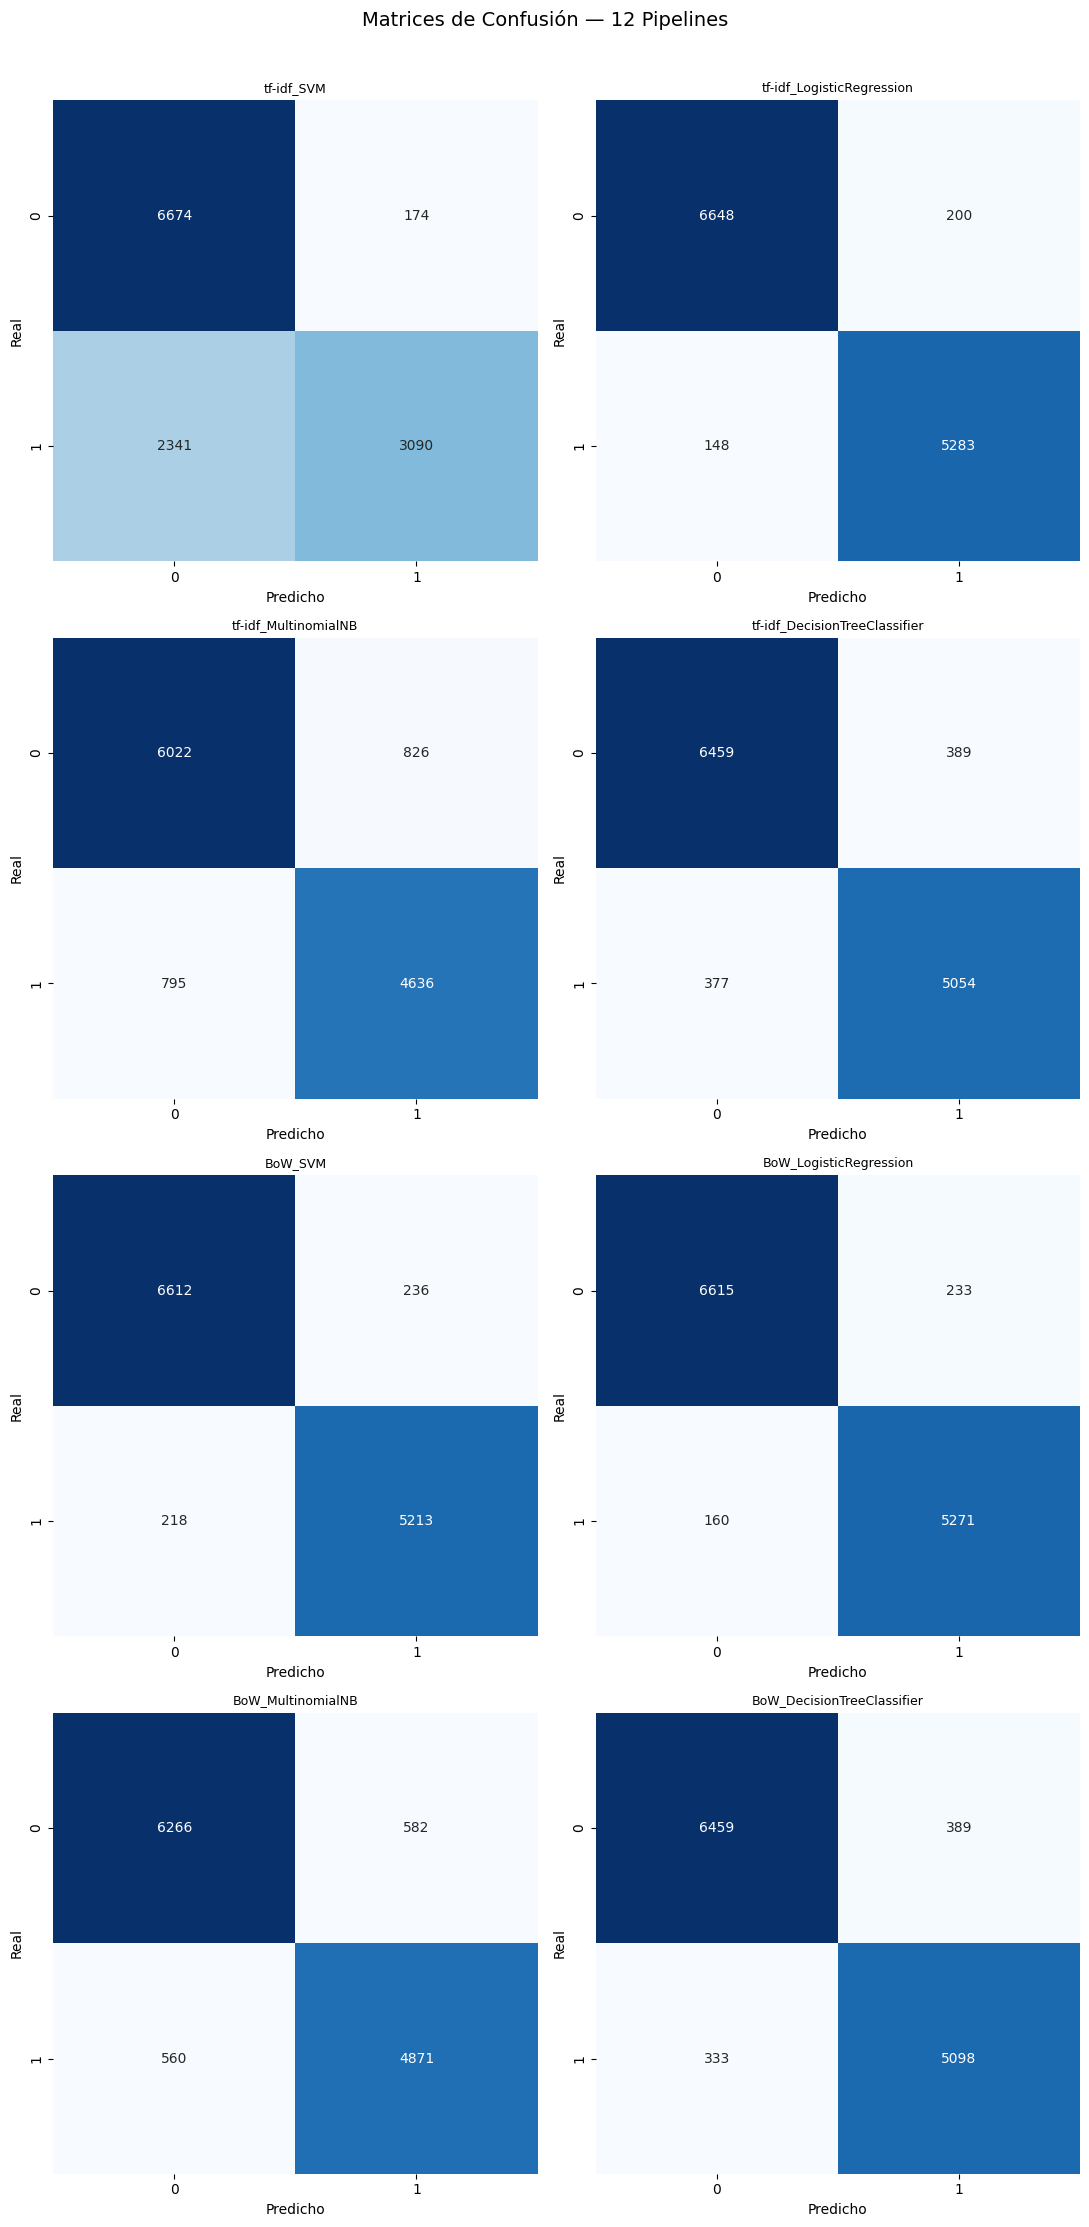

In [113]:
fig, axes = plt.subplots(4, 2, figsize=(11,22))
axes = axes.flatten()

for i, (pipeline_name, CV_grid) in enumerate(CV_grids.items()):
    y_pred = CV_grid['grid'].predict(CV_grid['X_test'])
    cm = skl.metrics.confusion_matrix(CV_grid['y_test'], y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        cbar=False
    )
    axes[i].set_title(pipeline_name, fontsize=9)
    axes[i].set_xlabel("Predicho")
    axes[i].set_ylabel("Real")

plt.suptitle("Matrices de Confusión — 12 Pipelines", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

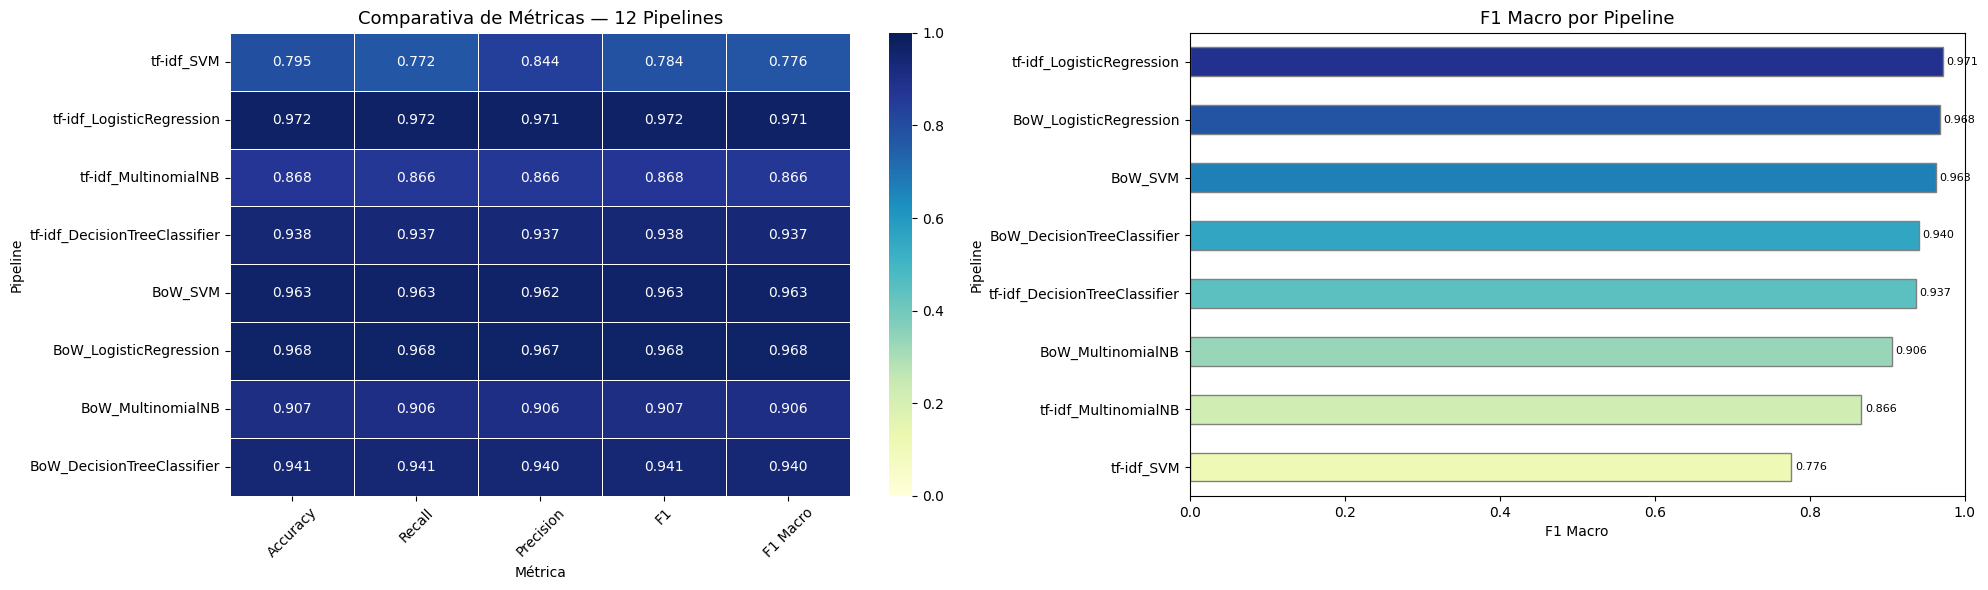

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(
    results_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    ax=axes[0],
    vmin=0,
    vmax=1,
    linewidths=0.5
)
axes[0].set_title("Comparativa de Métricas — 12 Pipelines", fontsize=13)
axes[0].set_xlabel("Métrica")
axes[0].set_ylabel("Pipeline")
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

results_df["F1 Macro"].sort_values(ascending=True).plot(
    kind="barh",
    ax=axes[1],
    color=sns.color_palette("YlGnBu", len(results_df)),
    edgecolor="gray"
)

axes[1].set_title("F1 Macro por Pipeline", fontsize=13)
axes[1].set_xlabel("F1 Macro")
axes[1].set_ylabel("Pipeline")
axes[1].set_xlim(0, 1)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.3f}",
        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()